# Search Queries Anomaly Detection - Arama Sorgularında Anomali Tespiti

Anomali tespiti (anomaly detection), verinin geri kalanından farklı davranan kayıtları bulma işidir. Bu projede bir web sitesinin arama motoru performans verisini (Google Search Console) inceleyeceğiz. Her satır bir arama sorgusu ve şu bilgileri içeriyor: tıklama, gösterim, CTR ve ortalama sıralama.

In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns',100)

import warnings
warnings.filterwarnings('ignore')

import re
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Queries.csv')

In [3]:
df.head()

,Top queries,Clicks,Impressions,CTR,Position
0,number guessing game python,5223,14578,35.83%,1.61
1,thecleverprogrammer,2809,3456,81.28%,1.02
2,python projects with source code,2077,73380,2.83%,5.94
3,classification report in machine learning,2012,4959,40.57%,1.28
4,the clever programmer,1931,2528,76.38%,1.09


In [4]:
df.shape

(1000, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Top queries  1000 non-null   object 
 1   Clicks       1000 non-null   int64  
 2   Impressions  1000 non-null   int64  
 3   CTR          1000 non-null   object 
 4   Position     1000 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 39.2+ KB


In [6]:
df.isnull().sum()

Top queries    0
Clicks         0
Impressions    0
CTR            0
Position       0
dtype: int64

In [7]:
df['Top queries'].duplicated().sum()   # tekrar eden sorgu

np.int64(0)

In [8]:
df['CTR']=df['CTR'].str.rstrip('%').astype('float')/100

In [9]:
df.describe()

,Clicks,Impressions,CTR,Position
count,1000.0000,1000.000000,1000.000000,1000.000000
mean,172.2750,1939.466000,0.225726,3.985930
std,281.0221,4856.702605,0.165270,2.841842
min,48.0000,62.000000,0.002900,1.000000
25%,64.0000,311.000000,0.080750,2.010000
50%,94.0000,590.500000,0.197150,3.120000
75%,169.0000,1582.750000,0.340250,5.342500
max,5223.0000,73380.000000,0.854800,28.520000


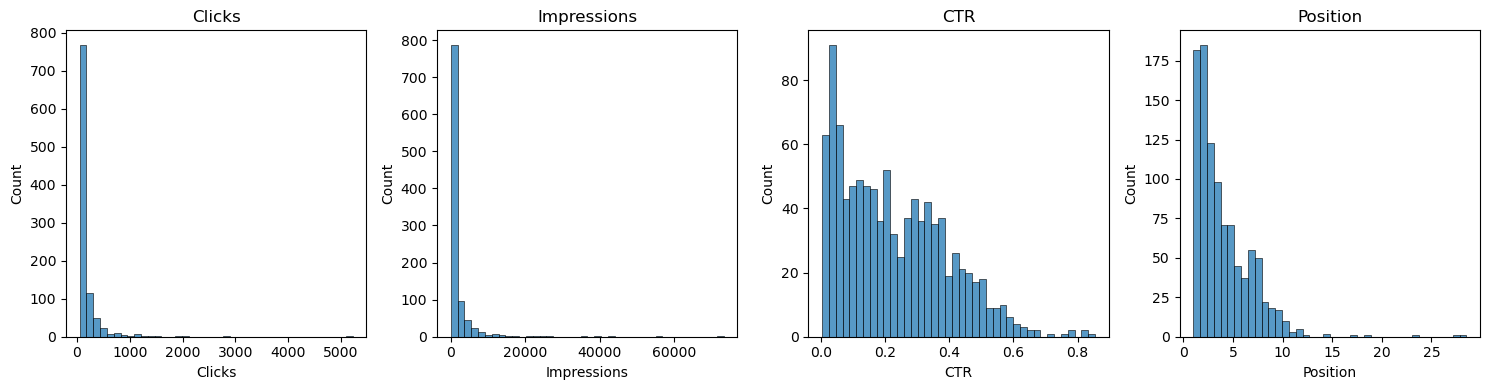

In [10]:
plt.figure(figsize=(15,4))
for i,c in enumerate(['Clicks','Impressions','CTR','Position'],1):
    plt.subplot(1,4,i)
    sns.histplot(df[c],bins=40)
    plt.title(c)
plt.tight_layout()
plt.show()

In [11]:
def kelimele(sorgu):
    return re.findall(r'\b[a-zA-Z]+\b',sorgu.lower())

kelimeler=Counter()
for s in df['Top queries']:
    kelimeler.update(kelimele(s))

kelime_df=pd.DataFrame(kelimeler.most_common(20),columns=['Kelime','Frekans'])
kelime_df.head()

,Kelime,Frekans
0,python,562
1,in,232
2,code,138
3,learning,133
4,machine,123


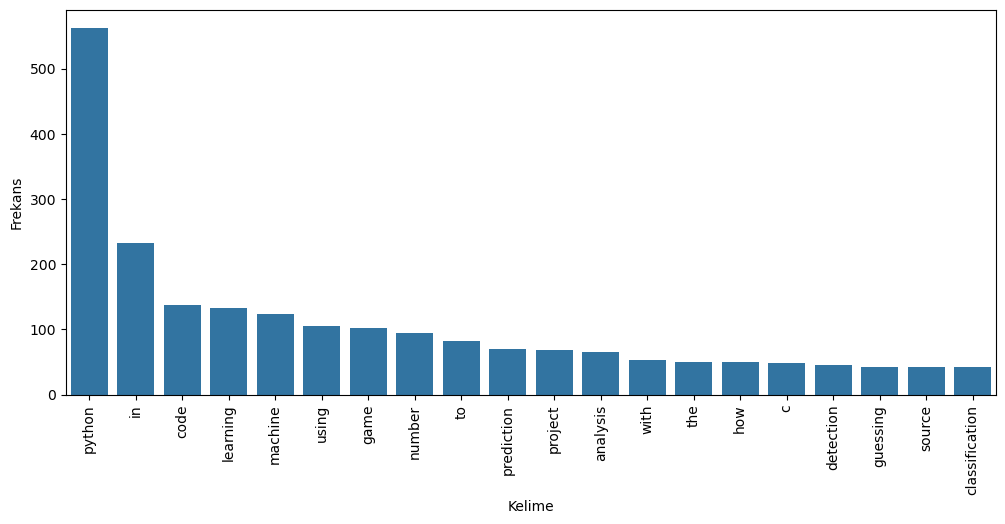

In [12]:
plt.figure(figsize=(12,5))
sns.barplot(x=kelime_df['Kelime'],y=kelime_df['Frekans'])
plt.xticks(rotation=90);

In [13]:
df.nlargest(10,'Clicks')[['Top queries','Clicks']]

,Top queries,Clicks
0,number guessing game python,5223
1,thecleverprogrammer,2809
2,python projects with source code,2077
3,classification report in machine learning,2012
4,the clever programmer,1931
5,standard scaler in machine learning,1559
6,aman kharwal,1490
7,python turtle graphics code,1455
8,python game projects with source code,1421
9,82 python projects with source code,1343


In [14]:
df.nlargest(10,'Impressions')[['Top queries','Impressions']]

,Top queries,Impressions
2,python projects with source code,73380
82,r2 score,56322
34,machine learning roadmap,42715
21,classification report,39896
232,standardscaler,39267
91,facebook programming languages,36055
15,rock paper scissors python,35824
36,pandas datareader,26663
180,classification_report,24917
54,pandas_datareader,24689


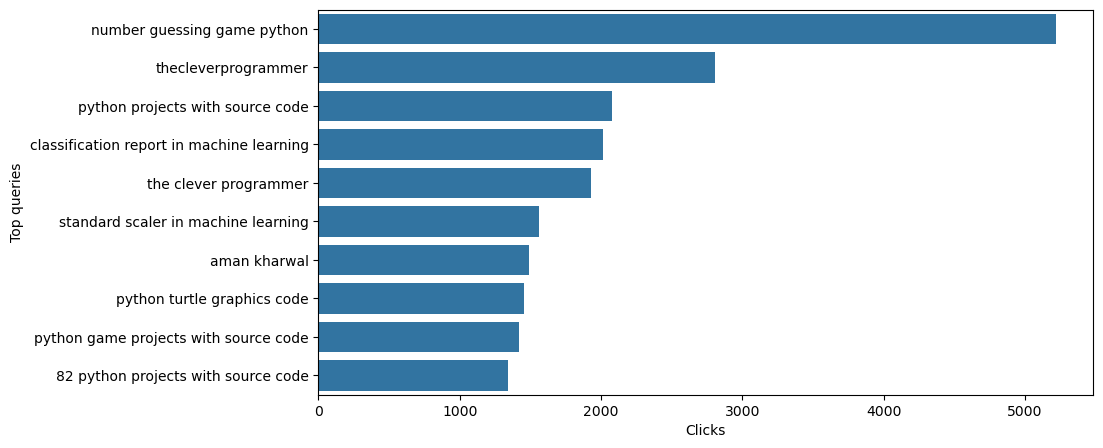

In [15]:
plt.figure(figsize=(10,5))
sns.barplot(y=df.nlargest(10,'Clicks')['Top queries'],x=df.nlargest(10,'Clicks')['Clicks']);

En yüksek ve en düşük CTR'ye sahip sorgular:

In [16]:
df.nlargest(10,'CTR')[['Top queries','CTR']]

,Top queries,CTR
928,the cleverprogrammer.com,0.8548
927,the clever programmer.com,0.8281
1,thecleverprogrammer,0.8128
732,the clever programmer python project,0.7857
307,the clever programmer machine learning projects,0.7735
4,the clever programmer,0.7638
964,python program to send otp to mobile,0.7083
95,the card game code in python,0.6699
771,write a python program that calculates number ...,0.6632
137,python program to calculate number of seconds ...,0.6585


In [17]:
df.nsmallest(10,'CTR')[['Top queries','CTR']]

,Top queries,CTR
929,python turtle,0.0029
232,standardscaler,0.0045
423,classification report sklearn,0.0047
544,standard scaler,0.0048
981,r2 score sklearn,0.0062
82,r2 score,0.0065
536,python source code,0.0067
664,online payment fraud detection,0.0070
684,turtle graphics,0.0070
858,water quality analysis,0.0076


Değişkenler arası ilişki:

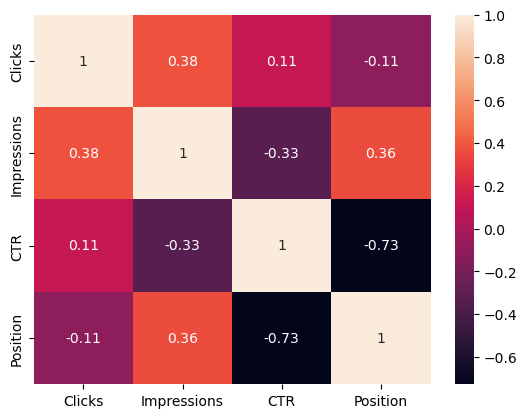

In [18]:
sns.heatmap(df[['Clicks','Impressions','CTR','Position']].corr(),annot=True);

In [19]:
from sklearn.ensemble import IsolationForest

In [20]:
x=df[['Clicks','Impressions','CTR','Position']]

In [21]:
iso=IsolationForest(n_estimators=100,contamination=0.01,random_state=42)
df['anomali_ham']=iso.fit_predict(x)   # -1 anomali, 1 normal

In [22]:
df['anomali_ham'].value_counts()

anomali_ham
 1    990
-1     10
Name: count, dtype: int64

In [23]:
df[df['anomali_ham']==-1][['Top queries','Clicks','Impressions','CTR','Position']]

,Top queries,Clicks,Impressions,CTR,Position
0,number guessing game python,5223,14578,0.3583,1.61
1,thecleverprogrammer,2809,3456,0.8128,1.02
2,python projects with source code,2077,73380,0.0283,5.94
4,the clever programmer,1931,2528,0.7638,1.09
15,rock paper scissors python,1111,35824,0.0310,7.19
21,classification report,933,39896,0.0234,7.53
34,machine learning roadmap,708,42715,0.0166,8.97
82,r2 score,367,56322,0.0065,9.33
232,standardscaler,177,39267,0.0045,10.23
929,python turtle,52,18228,0.0029,18.75


In [24]:
for seed in [1,2,3]:
    m=IsolationForest(n_estimators=100,contamination=0.01,random_state=seed).fit(x)
    print(seed, sorted(df[m.predict(x)==-1].index))

1 [0, 1, 2, 4, 11, 15, 21, 34, 82, 929]
2 [0, 1, 2, 4, 15, 21, 34, 82, 91, 232]
3 [0, 1, 2, 4, 15, 21, 34, 82, 167, 858]


In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
xl=x.copy()
xl['Clicks']=np.log1p(xl['Clicks'])
xl['Impressions']=np.log1p(xl['Impressions'])
xs=StandardScaler().fit_transform(xl)

In [27]:
iso2=IsolationForest(n_estimators=200,contamination=0.01,random_state=42)
df['anomali']=iso2.fit_predict(xs)
df['skor']=iso2.decision_function(xs)   # ne kadar küçükse o kadar anormal

In [28]:
df['anomali'].value_counts()

anomali
 1    990
-1     10
Name: count, dtype: int64

In [29]:
df[df['anomali']==-1].sort_values('skor')[['Top queries','Clicks','Impressions','CTR','Position','skor']]

,Top queries,Clicks,Impressions,CTR,Position,skor
1,thecleverprogrammer,2809,3456,0.8128,1.02,-0.067324
4,the clever programmer,1931,2528,0.7638,1.09,-0.053109
929,python turtle,52,18228,0.0029,18.75,-0.038809
167,text to handwriting,222,11283,0.0197,28.52,-0.038049
2,python projects with source code,2077,73380,0.0283,5.94,-0.035069
858,water quality analysis,56,7359,0.0076,27.56,-0.032956
0,number guessing game python,5223,14578,0.3583,1.61,-0.028939
928,the cleverprogrammer.com,53,62,0.8548,1.00,-0.011971
927,the clever programmer.com,53,64,0.8281,1.00,-0.008567
381,data science research topics,118,1718,0.0687,23.60,-0.001425


In [30]:
for seed in [1,2,3]:
    m=IsolationForest(n_estimators=200,contamination=0.01,random_state=seed).fit(xs)
    print(seed, sorted(df[m.predict(xs)==-1].index))

1 [0, 1, 2, 4, 15, 21, 34, 167, 858, 929]
2 [0, 1, 2, 4, 15, 21, 34, 167, 858, 929]
3 [0, 1, 2, 4, 21, 167, 858, 927, 928, 929]


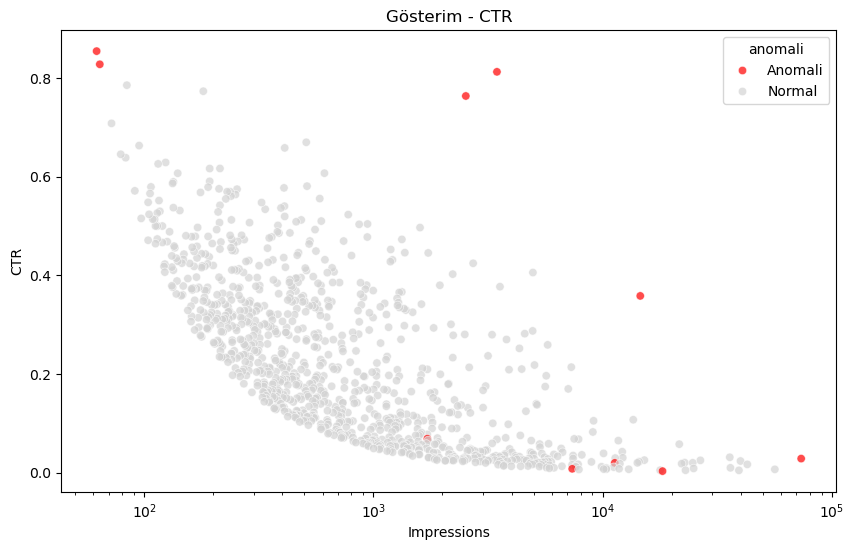

In [31]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Impressions',y='CTR',hue=df['anomali'].map({1:'Normal',-1:'Anomali'}),
                palette={'Normal':'lightgrey','Anomali':'red'},alpha=.7)
plt.xscale('log')
plt.title('Gösterim - CTR');

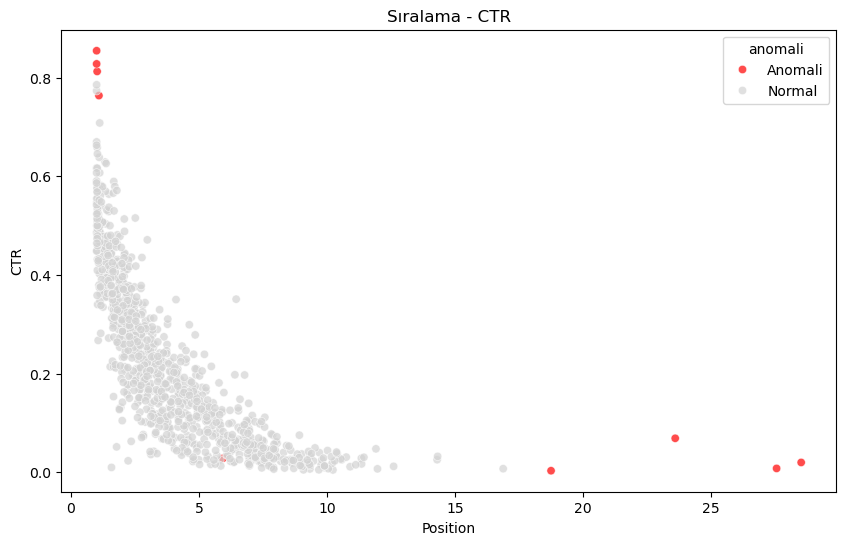

In [32]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Position',y='CTR',hue=df['anomali'].map({1:'Normal',-1:'Anomali'}),
                palette={'Normal':'lightgrey','Anomali':'red'},alpha=.7)
plt.title('Sıralama - CTR');

#### Anomaliler ne anlama geliyor?

Basit kurallarla anomalilere bir yorum ekleyelim. Eşikleri verinin kendisinden (yüzdelik dilimlerden) alıyoruz.

In [33]:
def yorum(satir):
    if satir['CTR']>=df['CTR'].quantile(.95):
        return 'Çok yüksek CTR (marka/doğrudan arama)'
    elif satir['Position']>=df['Position'].quantile(.95):
        return 'Çok düşük sıralama'
    elif satir['CTR']<=df['CTR'].quantile(.05):
        return 'Çok düşük CTR'
    else:
        return 'Diğer'

In [34]:
anomaliler=df[df['anomali']==-1].copy()
anomaliler['yorum']=anomaliler.apply(yorum,axis=1)
anomaliler[['Top queries','Clicks','Impressions','CTR','Position','yorum']]

,Top queries,Clicks,Impressions,CTR,Position,yorum
0,number guessing game python,5223,14578,0.3583,1.61,Diğer
1,thecleverprogrammer,2809,3456,0.8128,1.02,Çok yüksek CTR (marka/doğrudan arama)
2,python projects with source code,2077,73380,0.0283,5.94,Diğer
4,the clever programmer,1931,2528,0.7638,1.09,Çok yüksek CTR (marka/doğrudan arama)
167,text to handwriting,222,11283,0.0197,28.52,Çok düşük sıralama
381,data science research topics,118,1718,0.0687,23.60,Çok düşük sıralama
858,water quality analysis,56,7359,0.0076,27.56,Çok düşük sıralama
927,the clever programmer.com,53,64,0.8281,1.00,Çok yüksek CTR (marka/doğrudan arama)
928,the cleverprogrammer.com,53,62,0.8548,1.00,Çok yüksek CTR (marka/doğrudan arama)
929,python turtle,52,18228,0.0029,18.75,Çok düşük sıralama


In [35]:
anomaliler['yorum'].value_counts()

yorum
Çok yüksek CTR (marka/doğrudan arama)    4
Çok düşük sıralama                       4
Diğer                                    2
Name: count, dtype: int64

In [36]:
from sklearn.cluster import DBSCAN

In [37]:
for eps in [0.5,0.7,1.0,1.3]:
    etiket=DBSCAN(eps=eps,min_samples=5).fit_predict(xs)
    print(eps,'anomali sayısı:',(etiket==-1).sum(),' küme sayısı:',len(set(etiket))-(1 if -1 in etiket else 0))

0.5 anomali sayısı: 60  küme sayısı: 1
0.7 anomali sayısı: 25  küme sayısı: 2
1.0 anomali sayısı: 11  küme sayısı: 1
1.3 anomali sayısı: 8  küme sayısı: 1


In [38]:
db=DBSCAN(eps=0.7,min_samples=5)
df['dbscan']=db.fit_predict(xs)

In [39]:
df[df['dbscan']==-1][['Top queries','Clicks','Impressions','CTR','Position']].head(25)

,Top queries,Clicks,Impressions,CTR,Position
0,number guessing game python,5223,14578,0.3583,1.61
1,thecleverprogrammer,2809,3456,0.8128,1.02
2,python projects with source code,2077,73380,0.0283,5.94
4,the clever programmer,1931,2528,0.7638,1.09
7,python turtle graphics code,1455,13585,0.1071,4.60
11,clever programmer,1243,21566,0.0576,4.82
15,rock paper scissors python,1111,35824,0.0310,7.19
21,classification report,933,39896,0.0234,7.53
34,machine learning roadmap,708,42715,0.0166,8.97
36,pandas datareader,662,26663,0.0248,5.82


In [40]:
ortak=df[(df['anomali']==-1)&(df['dbscan']==-1)]
print('Isolation Forest:',(df['anomali']==-1).sum(),'DBSCAN:',(df['dbscan']==-1).sum(),'Ortak:',len(ortak))
ortak[['Top queries','Clicks','Impressions','CTR','Position']]

Isolation Forest: 10 DBSCAN: 25 Ortak: 10


,Top queries,Clicks,Impressions,CTR,Position
0,number guessing game python,5223,14578,0.3583,1.61
1,thecleverprogrammer,2809,3456,0.8128,1.02
2,python projects with source code,2077,73380,0.0283,5.94
4,the clever programmer,1931,2528,0.7638,1.09
167,text to handwriting,222,11283,0.0197,28.52
381,data science research topics,118,1718,0.0687,23.60
858,water quality analysis,56,7359,0.0076,27.56
927,the clever programmer.com,53,64,0.8281,1.00
928,the cleverprogrammer.com,53,62,0.8548,1.00
929,python turtle,52,18228,0.0029,18.75


In [41]:
anomaliler[['Top queries','Clicks','Impressions','CTR','Position','skor','yorum']].sort_values('skor').to_csv('anomaliler.csv',index=False)